# HH special-case (BP) rule: how often is it applied, and why?

`precision_HH` computes two candidate upper limits and reports whichever is larger:

- **main rule**: `ULE_main = EE + SE_main`, where `SE_main = z_score * sr * BVs / sqrt(ns)` and `sr = std(E/BV)` over the *whole* non-certainty sample -- this is the standard variance-based Hansen-Hurwitz precision, and it depends directly on the errors actually observed in the sample.
- **special-case rule**: `ULE_spec = EEe + BP_binomial`, where `BP_binomial = SI * ns * Beta⁻¹(cl; 1, ns)` is the Binomial Stringer bound's own basic-precision (zero-error) term. This does **not** depend on the observed taints at all -- only on `SI`, `ns`, and `cl`. It's a fixed floor: the precision a Stringer-type bound would require even if nothing at all had been found.

`ULE = max(ULE_main, ULE_spec)`. Because `SE_main` is the *only* one of the two that reacts to what was actually observed, whether the special case wins comes down to whether the observed-variability estimate is large enough to clear the fixed floor -- and with very few errors in a sample (most values are 0), `sr` can end up small purely because there isn't much data to estimate a spread from, regardless of how large or small the one or two real taints happen to be.

**Part 1** walks through four concrete, labeled cases (0 errors, few errors with the rule applied, few errors with it not applied, and more errors with it not applied) with every component of both formulas shown side by side, so you can see *why* one wins in each case.

**Part 2** repeats the earlier zero-error/conditional-rate split, but now across the full `BV_pop x f_target x corr_target x r_target` grid using the real simulation output (all 10,000 iterations per cell, not a redrawn sample), matching the scope of `main_simulation_results.xlsx` and `bp_usage_data.xlsx`.

No conclusions are asserted — read the tables/plots and draw your own.

In [1]:
import sys
sys.path.insert(0, "..")

import re
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist
from tqdm import tqdm

from create_population.import_population import import_population
from simulation.sample import Sample

pd.set_option("display.float_format", lambda x: f"{x:,.4f}" if abs(x) < 10 else f"{x:,.0f}")
CL = 0.90  # confidence level used throughout Part 1

## Part 1 — Four labeled cases, every component shown

One real population (`BV_15pct_above_SI`, `f_target=0.05`, `corr_target=0.25`, `r_target=0.01`), sample size 30. The cell below searches random draws until it finds:

1. a sample with **0 errors** (the rule always wins here -- `sr` is exactly 0, so `SE_main=0`),
2. a sample with **1-2 errors where the rule is applied**,
3. a sample with **1-2 errors where the rule is *not* applied**, for direct contrast, and
4. a sample with **3+ errors where the rule is not applied** (the more "typical" expectation).

In [2]:
def draw_hh_sample(pop, N, BV, EE_true, sample_size, random_state):
    s = Sample(
        population=pop, N=N, EE=EE_true, BV=BV, sample_size=sample_size, cl=CL, z_score=1.2816,
        hv_selection="iterative", selection_type="systematic_sampling",
        bound_estimator="HH", random_state=random_state,
    )
    s.run()
    return s


def decomposed_report(sample_obj, cl=CL):
    """Every component of both candidate ULEs for one already-drawn HH sample."""
    sample_s = sample_obj.sample_s
    ns = len(sample_s)
    BVs, SI, z_score = sample_obj.BVs, sample_obj.SI, sample_obj.z_score
    EE, EEe = sample_obj.EE_pred, sample_obj.EEe

    sr = np.std(sample_s["E"] / sample_s["BV"], ddof=1)
    SE_main = z_score * sr * BVs / np.sqrt(ns)

    reliability_factor = ns * beta_dist.ppf(q=cl, a=1, b=ns)
    BP_binom = SI * reliability_factor

    ULE_main = EE + SE_main
    ULE_spec = EEe + BP_binom
    rule_applied = ULE_spec > ULE_main

    return {
        "number_errors": sample_obj.number_errors,
        "ns": ns,
        "EE_pred": EE,
        "EEe (certainty stratum error)": EEe,
        "sr = std(E/BV)": sr,
        "z_score": z_score,
        "BVs": BVs,
        "SE_main = z*sr*BVs/sqrt(ns)": SE_main,
        "SI": SI,
        "cl": cl,
        "reliability_factor = ns*Beta^-1(cl,1,ns)": reliability_factor,
        "BP_binom = SI*reliability_factor": BP_binom,
        "ULE_main (= EE + SE_main)": ULE_main,
        "ULE_spec (= EEe + BP_binom)": ULE_spec,
        "rule_applied (spec > main)": rule_applied,
        "SE reported by precision_HH": sample_obj.SE,
    }

In [3]:
pop = import_population(BV_pop="BV_15pct_above_SI", f_target=0.05, corr_target=0.25, r_target=0.01)
BV, N, EE_true = pop["BV"].sum(), len(pop), pop["E"].sum()
SAMPLE_SIZE_PART1 = 30

zero_err = few_err_applied = few_err_not_applied = many_err_not_applied = many_err_applied = None
for rs in range(50_000):
    s = draw_hh_sample(pop, N, BV, EE_true, sample_size=SAMPLE_SIZE_PART1, random_state=rs)
    applied = not np.isclose(s.ULE_HH, s.ULE)
    if s.number_errors == 0 and zero_err is None:
        zero_err = s
    elif 0 < s.number_errors <= 2 and applied and few_err_applied is None:
        few_err_applied = s
    elif 0 < s.number_errors <= 2 and not applied and few_err_not_applied is None:
        few_err_not_applied = s
    elif s.number_errors >= 3 and applied and many_err_not_applied is None:
        many_err_applied = s
    elif s.number_errors >= 3 and not applied and many_err_not_applied is None:
        many_err_not_applied = s
    if all(x is not None for x in [zero_err, few_err_applied, few_err_not_applied, many_err_not_applied, many_err_applied]):
        break

cases = {
    "0 errors": zero_err,
    "1-2 errors, rule applied": few_err_applied,
    "1-2 errors, rule NOT applied": few_err_not_applied,
    "3+ errors, rule applied": many_err_applied,
    "3+ errors, rule NOT applied": many_err_not_applied,
}
missing = [label for label, s in cases.items() if s is None]
if missing:
    print(f"Could not find an example for: {missing} within the search budget -- increase the range above if you need it.")

part1 = pd.DataFrame({label: decomposed_report(s) for label, s in cases.items() if s is not None})
part1

Could not find an example for: ['3+ errors, rule applied'] within the search budget -- increase the range above if you need it.


,0 errors,"1-2 errors, rule applied","1-2 errors, rule NOT applied","3+ errors, rule NOT applied"
number_errors,0,1,2,3
ns,30,30,30,30
EE_pred,0.0000,"2,485,243","116,684,556","230,883,868"
EEe (certainty stratum error),0,0,0,0
sr = std(E/BV),0.0000,0.0040,0.1825,0.2535
z_score,1.2816,1.2816,1.2816,1.2816
BVs,"3,425,979,382","3,425,979,382","3,425,979,382","3,425,979,382"
SE_main = z*sr*BVs/sqrt(ns),0.0000,"3,185,087","146,282,647","203,248,116"
SI,"114,199,313","114,199,313","114,199,313","114,199,313"
cl,0.9000,0.9000,0.9000,0.9000


### Reading Part 1

Compare `sr = std(E/BV)` and the resulting `SE_main` across the columns: in the "1-2 errors" columns, `sr` is computed from a sample that's almost entirely zeros with one or two nonzero values, so it can come out small (or not) almost independently of `ns` — while `BP_binom` in the same rows is identical regardless of what those one or two values actually were, since it never looks at the taints at all. The "3+ errors" column is there so you can see a case with more observed variability comfortably clearing the fixed floor, for contrast.

## Part 2 — Full grid, using the real simulation output (not redrawn samples)

Reads every `results_*.xlsx` file directly (all 10,000 iterations per `(sample_size, confidence_level)` cell, matching `main_simulation_results.xlsx` / `bp_usage_data.xlsx` exactly) and, for each cell, splits `% BP rule used` into the zero-error share and the conditional (has-errors) share -- the same decomposition worked through in chat, generalized across the whole grid instead of one combination.

This reads all 108 files and takes roughly 10 minutes. Set `FILES_LIMIT` below to a small number (e.g. 12) for a quick, partial-grid run instead.

In [4]:
FILES_LIMIT = None  # e.g. 12 for a quick partial run; None reads the full grid (~10 minutes)

files = sorted(glob.glob("../results/results_*.xlsx"))
if FILES_LIMIT:
    files = files[:FILES_LIMIT]
print(f"Reading {len(files)} file(s)...")

pattern = r"^results_BV_(?P<bv>\d+pct)_above_SI_F(?P<f>[\d.]+)_C(?P<c>[\d.]+)_R(?P<r>[\d.]+)\.xlsx$"
rows = []

for file in tqdm(files):
    results = pd.read_excel(
        file, sheet_name=0, engine="calamine",
        usecols=["sample_size", "confidence_level", "bound_estimator", "ULE_pred", "ULE_HH", "number_errors"],
    )
    m = re.match(pattern, os.path.basename(file))
    if m is None:
        raise ValueError(f"Filename didn't match pattern: {file}")
    extracted = m.groupdict()

    hh = results[results["bound_estimator"] == "HH"].copy()
    hh["BP_used"] = hh["ULE_HH"] != hh["ULE_pred"]
    hh["has_errors"] = hh["number_errors"] > 0

    for (ss, cl), grp in hh.groupby(["sample_size", "confidence_level"]):
        n_total = len(grp)
        n_zero = int((~grp["has_errors"]).sum())
        n_err = int(grp["has_errors"].sum())
        rows.append({
            "BV_pop": extracted["bv"], "f_target": float(extracted["f"]),
            "corr_target": float(extracted["c"]), "r_target": float(extracted["r"]),
            "sample_size": ss, "confidence_level": cl,
            "n_iterations": n_total,
            "% zero-error": n_zero / n_total,
            "% BP used (overall)": grp["BP_used"].mean(),
            "% BP used | zero errors": grp.loc[~grp["has_errors"], "BP_used"].mean() if n_zero else np.nan,
            "% BP used | has errors": grp.loc[grp["has_errors"], "BP_used"].mean() if n_err else np.nan,
        })

grid = pd.DataFrame(rows)
grid.to_excel("../results/hh_special_case_grid.xlsx", index=False)
print(f"{len(grid)} (population, sample_size, confidence_level) rows written to ../results/hh_special_case_grid.xlsx")

Reading 108 file(s)...



  0%|          | 0/108 [00:00<?, ?it/s]


  1%|          | 1/108 [00:05<09:21,  5.25s/it]


  2%|▏         | 2/108 [00:10<09:45,  5.53s/it]


  3%|▎         | 3/108 [00:17<10:14,  5.85s/it]

...


 98%|█████████▊| 106/108 [17:20<00:24, 12.31s/it]


 99%|█████████▉| 107/108 [17:32<00:12, 12.34s/it]


100%|██████████| 108/108 [17:45<00:00, 12.35s/it]


100%|██████████| 108/108 [17:45<00:00,  9.86s/it]

1620 (population, sample_size, confidence_level) rows written to ../results/hh_special_case_grid.xlsx


### Grid-wide averages, by sample size (matches the scope of your pivot tables)

In [5]:
grid80 = grid[grid["confidence_level"] == 0.8]
grid80.groupby("sample_size")[["% zero-error", "% BP used (overall)", "% BP used | zero errors", "% BP used | has errors"]].mean()

,% zero-error,% BP used (overall),% BP used | zero errors,% BP used | has errors
sample_size,,,,
30,0.0355,0.7256,1.0000,0.7113
65,0.1400,0.4909,1.0000,0.3511
100,0.0994,0.4104,1.0000,0.3113
150,0.0732,0.2996,1.0000,0.2265
200,0.0591,0.2389,1.0000,0.1798


### Same breakdown, by `f_target` and by `r_target`

(`% BP used | zero errors` is always ~100% by construction and is dropped here since it adds nothing new — the interesting column is the last one.)

In [6]:
for group_col in ["f_target", "r_target"]:
    print(f"--- by {group_col} (CL=80%) ---")
    display(
        grid80.groupby([group_col, "sample_size"])["% BP used | has errors"]
        .mean()
        .unstack("sample_size")
    )

--- by f_target (CL=80%) ---


sample_size,30,65,100,150,200
f_target,,,,,
0.0500,0.6015,0.0602,0.0451,0.0363,0.0311
0.2000,0.6794,0.4854,0.4327,0.3181,0.2562
0.5000,0.8531,0.5077,0.4562,0.3249,0.2521


--- by r_target (CL=80%) ---


sample_size,30,65,100,150,200
r_target,,,,,
0.0020,0.9811,0.7023,0.7011,0.6985,0.6949
0.0100,0.9062,0.6483,0.5410,0.2070,0.0242
0.0300,0.5557,0.0397,0.0024,0.0003,0.0001
0.0400,0.4022,0.0142,0.0008,0.0001,0.0000


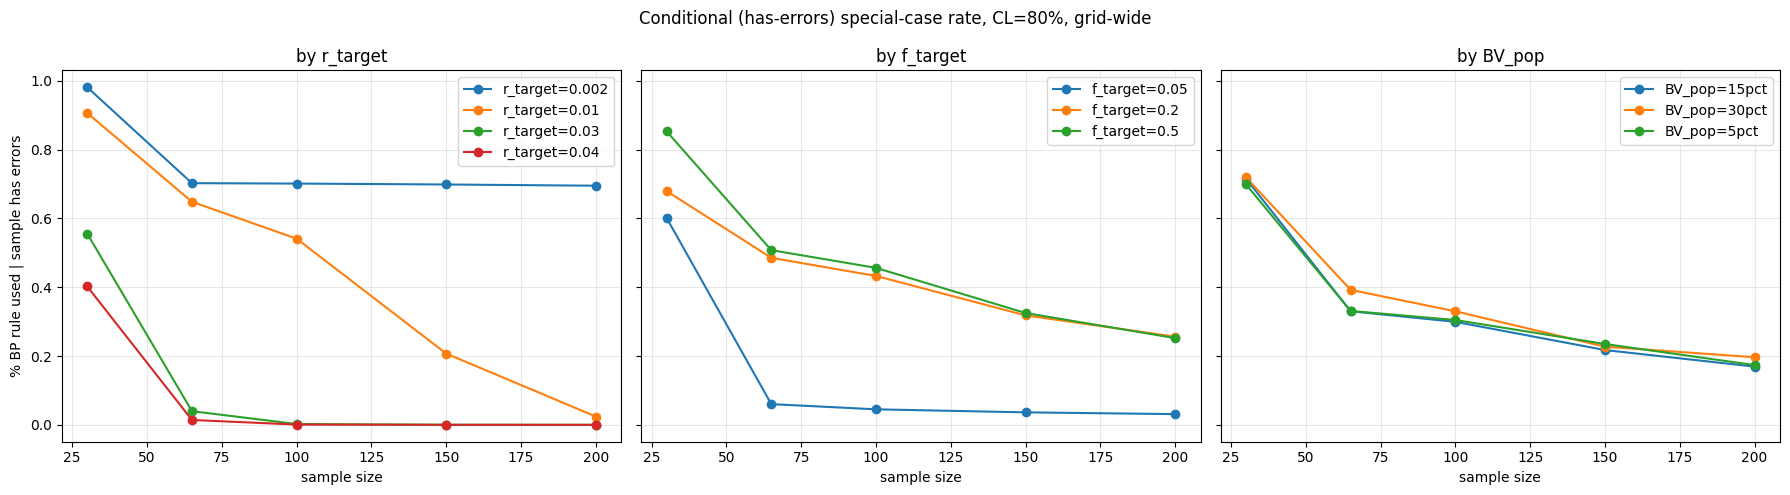

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for r, grp in grid80.groupby("r_target"):
    m = grp.groupby("sample_size")["% BP used | has errors"].mean()
    axes[0].plot(m.index, m.values, marker="o", label=f"r_target={r}")
axes[0].set_title("by r_target")
axes[0].legend()

for f, grp in grid80.groupby("f_target"):
    m = grp.groupby("sample_size")["% BP used | has errors"].mean()
    axes[1].plot(m.index, m.values, marker="o", label=f"f_target={f}")
axes[1].set_title("by f_target")
axes[1].legend()

for bv, grp in grid80.groupby("BV_pop"):
    m = grp.groupby("sample_size")["% BP used | has errors"].mean()
    axes[2].plot(m.index, m.values, marker="o", label=f"BV_pop={bv}")
axes[2].set_title("by BV_pop")
axes[2].legend()

for ax in axes:
    ax.set_xlabel("sample size")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("% BP rule used | sample has errors")
fig.suptitle("Conditional (has-errors) special-case rate, CL=80%, grid-wide")
plt.tight_layout()
plt.show()

## Notes for interpretation

- Part 1's `BP_binom` and `HH_basic_precision` in the earlier notebook are the same formula; here it's spelled out fully (`SI`, `ns`, `cl`, the reliability factor itself, then the multiplication) so every number that feeds into it is visible.
- `% BP used | zero errors` is included in the grid for completeness but is always at (or extremely close to) 100% -- it is not the interesting number. `% BP used | has errors` is the one that answers "is the rule firing more than expected, given that there is real evidence of error."
- The full grid (`FILES_LIMIT = None`) takes about 10 minutes to read; the result is also saved to `../results/hh_special_case_grid.xlsx` so you don't have to re-run the read to work with it again.
- No summary verdict is given here on purpose — read the tables and the three panels of the plot and draw your own conclusions about where the special case is over- or under-firing, and why.